# Lab2 NonMarkov Path Plot

This notebook simulates the non-Markovian dynamics and keeps one unwrapped x-y trajectory so the path can be plotted directly.

Parameter choices are tuned for the question of forced Brownian motion with memory. `N=100` gives a stable ensemble average without making each run too expensive. `L=100` is large enough that periodic wraparound should not dominate the motion over the window of interest. `D=0.01` keeps the stochastic forcing visible while still allowing the force response to be measured. `dt=1e-2` is small enough to resolve the OU update and the drift, while `T=1000` and `store_every=25` make the run long enough to see the scaling while keeping the simulation cost manageable.


In [1]:
# Imports
import numpy as np
import scipy.stats as sci
import matplotlib.pyplot as plt
import time

# for validation, random seed is randomly selected per tau/force combo
np.random.seed(7)


In [2]:
# Plot styles
plot_styles = {
    "linestyles": {
        "tau": ["dotted", "-", "dashed", (0, (1, 2)), (0, (2, 3)), (0, (3, 5))],
        "force": ["dotted", "-", "dashed", (0, (1, 2)), (0, (2, 3))],
        "summary": ["-", "--", ":"],
    },
    "markers": {
        "tau": ["o", "x", "^", "s", "d"],
        "force": ["o", "x", "^", "s", "d"],
        "summary": ["o", "x", "^"],
    },
    "colors": {
        "primary": "black",
        "secondary": "gray",
        "start": "green",
        "end": "black",
    },
}


In [3]:
def euler_mayurama(r, xi, eps, tau, f, dt=1e-3, D=1.0, L=100.0):
    """Advance the non-Markovian dynamics by one Euler-Maruyama step."""
    N = r.shape[0]
    eta = np.random.randn(N, 2)
    xi += -(dt / tau) * xi + np.sqrt(2 * D / tau**2) * np.sqrt(dt) * eta

    # Keep the force along x and let the noise drive both coordinates.
    F = np.zeros_like(r)
    F[:, 0] = f * eps
    r += (F + xi) * dt
    return r, xi


def noise_autocorrelation(xi_traj, store_every=1, dt=1e-2):
    nsteps, N, dim = xi_traj.shape
    max_lag = nsteps // 2
    C = np.zeros(max_lag)
    for lag in range(max_lag):
        prod = np.sum(xi_traj[:nsteps - lag] * xi_traj[lag:], axis=(1, 2))
        C[lag] = np.mean(prod)
    t_lags = np.arange(max_lag) * store_every * dt
    return t_lags, C


In [4]:
def msd_theory(t, D, tau):
    # MSD theory curve used for the zero-force tau comparisons.
    return 4 * D * (t + tau * (np.exp(-t / tau) - 1.0))


In [ ]:
# Parameters (before tau sweep simulation)
N = 100
L = 100.0
D = 0.01
taus = [1, 10, 100]
tau_force = 10
forces = [0.0, 1e-3, 1e-2, 1e-1, 1.0]
forces_mu = [1e-3, 1e-2, 1e-1, 1.0]
nrealizations = 20
nforce_realizations = 20
tau_params = {
    1: {"dt": 1e-2, "T": 5000.0, "store_every": 25},
    10: {"dt": 1e-2, "T": 5000.0, "store_every": 25},
    100: {"dt": 1e-2, "T": 10000.0, "store_every": 25},
}


## Tau runs
- Larger `tau` means longer-lived noise correlations.
- With zero force, the x-y trajectories should remain centered while spreading over time.
- Noise correlations should decay on a scale set by `tau`; the late-time floor is mostly sampling noise on log scales.


In [ ]:
# Zero-force tau sweep
f = 0.0
msd_all = {tau: [] for tau in taus}
path_all = {tau: [] for tau in taus}
noise_corr = {tau: [] for tau in taus}
tau_time = {}
t0 = time.time()
np.random.seed(None)  # reset seed to full random
forced_T = 1000
for tau_idx, tau in enumerate(taus):
    dt_tau = tau_params[tau]["dt"]
    T_tau = tau_params[tau]["T"]
    print(f"N={N}, L={L}, D={D}, T={T_tau}, dt={dt_tau}")
    store_every_tau = tau_params[tau]["store_every"]
    nsteps_tau = int(T_tau / dt_tau)
    nstore_tau = nsteps_tau // store_every_tau
    tau_time[tau] = np.arange(nstore_tau) * store_every_tau * dt_tau
    for realization in range(nrealizations):
        ftime = time.time()
        print(f"tau={tau}: {tau_idx+1}/{len(taus)} || run {realization+1}/{nrealizations} (f={f}) | dt={dt_tau}, T={T_tau}, store_every={store_every_tau}", end=" ")
        r = np.random.rand(N, 2) * L - L/2
        xi = np.zeros((N, 2))
        eps = np.random.choice([-1, 1], size=N)
        disp = np.zeros((N, 2))
        r0 = r.copy()
        noise_traj = np.zeros((nstore_tau, N, 2), dtype=np.float32)
        path_traj = np.zeros((nstore_tau, N, 2), dtype=np.float32)
        msd = np.zeros(nstore_tau, dtype=np.float32)
        store_idx = 0
        for k in range(1, nsteps_tau + 1):
            r_old = r.copy()
            r, xi = euler_mayurama(r, xi, eps, tau, f, dt=dt_tau, D=D, L=L)
            delta_r = r - r_old
            disp += delta_r
            r[:, 0] = ((r[:, 0] + L/2) % L) - L/2
            r[:, 1] = ((r[:, 1] + L/2) % L) - L/2

            if k % store_every_tau == 0:
                msd[store_idx] = np.mean(np.sum(disp**2, axis=1))
                noise_traj[store_idx] = delta_r / dt_tau
                path_traj[store_idx] = r0 + disp
                store_idx += 1
        t_lags, C_noise = noise_autocorrelation(noise_traj, store_every=store_every_tau, dt=dt_tau)
        noise_corr[tau].append((t_lags, C_noise))
        msd_all[tau].append(msd)
        path_all[tau].append(path_traj)
        #print(f"- running {time.time() - t0:.1f} s")
    print(f"===================f:{f} tau:{tau}====================== {(time.time() - t0)//60:.0f}:{(time.time() - t0)%60:.1f} s\n")
print(f"Finished in {time.time() - t0:.1f} s")


N=10, L=100.0, D=0.01, T=1000.0, dt=0.01
===================f:0.0 tau:1====================== 0:15.9 s

N=10, L=100.0, D=0.01, T=1000.0, dt=0.01
===================f:0.0 tau:10====================== 0:32.0 s

N=10, L=100.0, D=0.01, T=2500.0, dt=0.01
===================f:0.0 tau:100====================== 1:15.9 s

Finished in 75.9 s


## Tau Results
- The path plot should be read as three different persistence times on the same coordinate frame.
- `MSD_x(t)` should follow the theory curve; `|d_x(t)|` is more sensitive to finite-sample cancellation.
- Noise correlation plots should be interpreted by the decay scale, not the tiny log-scale floor.


In [7]:
# --- time array and plotting styles ---
tau_linestyles = plot_styles["linestyles"]["tau"]
tau_markers = plot_styles["markers"]["tau"]
print("Tau sweep stores path_all[tau][realization][time, particle, xy] and plots use a chosen realization/particle.")


Tau sweep stores path_all[tau][realization][time, particle, xy] and plots use a chosen realization/particle.


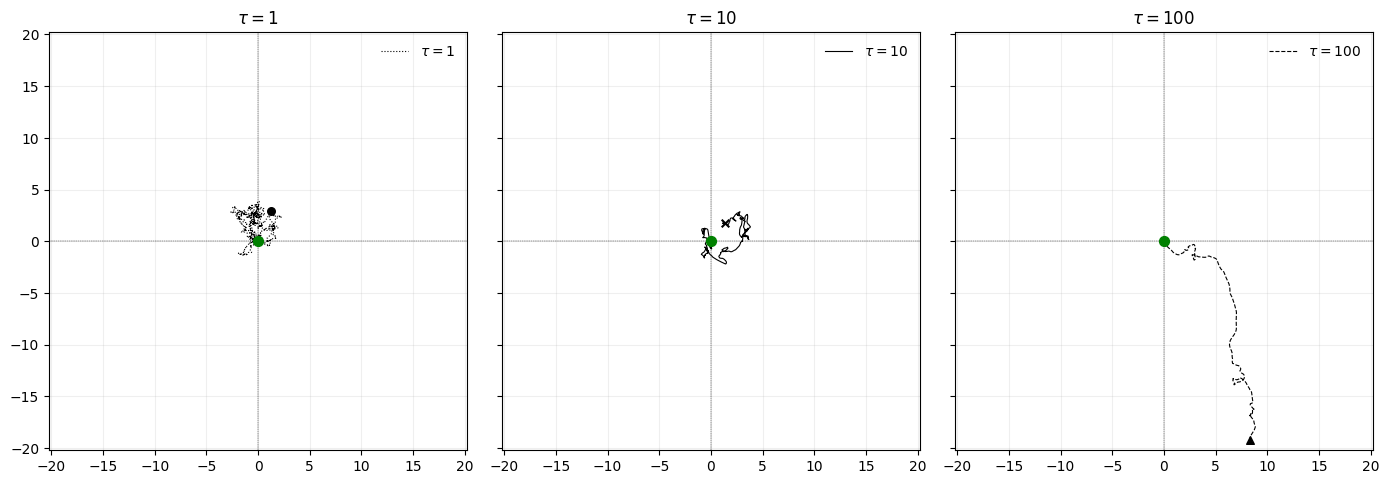

In [8]:
## Apply origin centering here ##

figure, ax = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)
paths = {}
max_extent = 0.0
particle_idx = np.random.randint(0,N)
for tau in taus:
    realization_idx = 0  # change this if you want a different run
    particle_idx = particle_idx      # change this if you want a different particle
    path = path_all[tau][realization_idx][:, particle_idx, :]
    path = path - path[0]
    paths[tau] = path
    max_extent = max(max_extent, np.max(np.abs(path[:, 0])), np.max(np.abs(path[:, 1])))

pad = 1.05 * max_extent if max_extent > 0 else 1.0
for tau_idx, tau in enumerate(taus):
    _plt = ax[tau_idx]
    path = paths[tau]
    _plt.plot(path[:, 0], path[:, 1], color=plot_styles["colors"]["primary"], linestyle=tau_linestyles[tau_idx % len(tau_linestyles)], linewidth=0.8, label=rf"$\tau={tau}$")
    _plt.scatter(path[0, 0], path[0, 1], color=plot_styles["colors"]["start"], s=50, marker="o", zorder=3)
    _plt.scatter(path[-1, 0], path[-1, 1], color=plot_styles["colors"]["end"], s=30, marker=tau_markers[tau_idx % len(tau_markers)])
    _plt.axvline(x=0, color=plot_styles["colors"]["primary"], linestyle="--", linewidth=0.3)
    _plt.axhline(y=0, color=plot_styles["colors"]["primary"], linestyle="--", linewidth=0.3)
    _plt.set_xlim(-pad, pad)
    _plt.set_ylim(-pad, pad)
    _plt.set_aspect("equal", adjustable="box")
    _plt.set_title(rf"$\tau={tau}$")
    _plt.grid(alpha=0.2)
    _plt.legend(frameon=False)

plt.tight_layout()
plt.show()


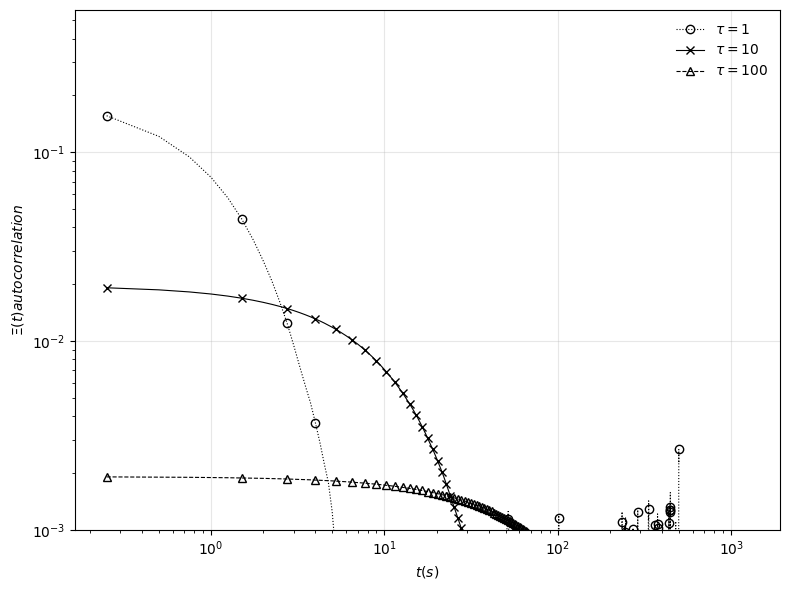

In [ ]:
# --- noise autocorrelation ---
plt.figure(figsize=(8, 6))
for tau_idx, tau in enumerate(taus):
    t_lags, C_mean = zip(*noise_corr[tau])
    t_lags = np.array(t_lags[0])
    C_mean = np.mean(np.array(C_mean), axis=0)
    plt.loglog(t_lags[1:], np.maximum(C_mean[1:], 1e-12), color=plot_styles["colors"]["primary"], linestyle=tau_linestyles[tau_idx % len(tau_linestyles)], linewidth=0.8, marker=tau_markers[tau_idx % len(tau_markers)], markevery=(0, 5), fillstyle="none", label=rf"$\tau={tau}$")
plt.xlabel(r"$t$")
plt.ylim(bottom=0.0005)
plt.ylabel(r"$\Xi(t) autocorrelation$")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

For this OU-style colored noise, the correlation is effectively back in the
  white-noise regime when
  - t >> tau

  - around t ~ 3 tau, the memory is already mostly gone
  - by t ~ 5 tau to 10 tau, the correlation is usually negligible for plotting
    and interpretation

  MSD(t) = 4D(t + tau(e^{-t/tau} - 1))

  - Early time, t << tau:
      - e^{-t/tau} ≈ 1 - t/tau + ...
      - so MSD(t) ≈ 2D t^2 / tau
      - this is ballistic-like growth, because the noise is still correlated
  - Late time, t >> tau:
      - e^{-t/tau} → 0
      - so MSD(t) ≈ 4D(t - tau)
      - the leading term is linear in t, which is the diffusive white-noise
        regime

  - tau is the memory time
  - before tau, the system “remembers” past kicks, so motion is smoother and
    more persistent
  - after several tau, the kicks are effectively uncorrelated, and the motion
    looks like ordinary Brownian diffusion

  - if  time axis on the order of 10 tau or larger, you are safely in the
    white-noise-like regime for the correlation and the asymptotic MSD slope




1:2
10:0
100:9


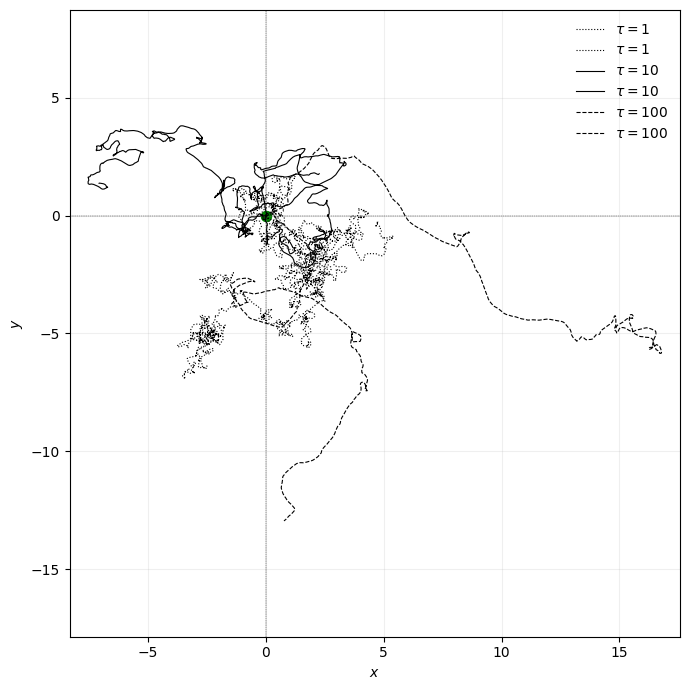

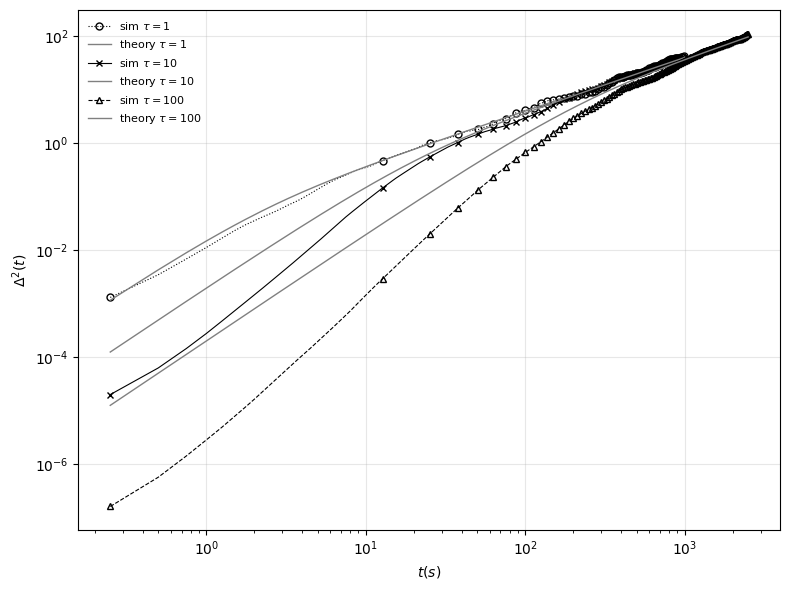

In [ ]:
# --- time array and plotting styles ---
tau_linestyles = plot_styles["linestyles"]["tau"]
tau_markers = plot_styles["markers"]["tau"]

# --- x-y path plot ---
plt.figure(figsize=(7, 7))

for tau_idx, tau in enumerate(taus):
    which = np.random.randint(0, len(path_all[tau]))
    print(f"{tau}:{which}")
    path = path_all[tau][which]
    path = path - path[0]
    plt.plot(path[:, 0], path[:, 1], color=plot_styles["colors"]["primary"], markevery=(0,-1),linestyle=tau_linestyles[tau_idx % len(tau_linestyles)], linewidth=0.8, label=rf"$\tau={tau}$")
    
    #plt.scatter(path[-1, 0], path[-1, 1], color=plot_styles["colors"]["end"], s=30, marker=tau_markers[tau_idx % len(tau_markers)])
plt.scatter(path[0, 0], path[0, 1], color='green', s=50, marker='o',zorder=0) 
plt.axvline(x=0, color=plot_styles["colors"]["primary"], linestyle="--", linewidth=0.3)
plt.axhline(y=0, color=plot_styles["colors"]["primary"], linestyle="--", linewidth=0.3)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.grid(alpha=0.2)
plt.legend(frameon=False)
plt.axis("equal")
plt.tight_layout()
plt.show()


# --- MSD plot with theory ---
plt.figure(figsize=(8, 6))
for tau_idx, tau in enumerate(taus):
    msd_mean = np.mean(msd_all[tau], axis=0)
    tt = tau_time[tau]
    plt.loglog(tt[1:], msd_mean[1:], marker=tau_markers[tau_idx % len(tau_markers)], 
               markersize=5, markevery=(0, 50), fillstyle="none", 
               linestyle=tau_linestyles[tau_idx % len(tau_linestyles)], 
               linewidth=0.8, color=plot_styles["colors"]["primary"], label=rf"sim $\tau={tau}$")
    plt.loglog(tt[1:], msd_theory(tt, D, tau)[1:], linestyle="-", linewidth=1.0, 
               color=plot_styles["colors"]["secondary"], label=rf"theory $\tau={tau}$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\Delta^2(t)$")
plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Force And Response Theory
- The x-force sweep should show the perturbation first in x because the force is only applied along x.
- Small forces should stay near the zero-force baseline and define the linear-response regime.
- The y-direction should remain centered near zero on average.
- Once the force-induced drift is no longer small compared with stochastic spread, the response should stop collapsing onto a single proportional curve in `f`.


## Force Sweep Plotting
- Plot these after the sweep so the labels and line choices can be adjusted without rerunning the simulations.
- Use the `tau = 10` slice for the original force-response plots.


In [ ]:
# Parameters (before force comparison at tau=10 simulation)
N = 50
D = 0.01
dt=0.01
T=2000
nsteps = int(T / dt)
taus = [1, 10, 100]
tau_force = 10
forces = [0.0, 1e-3, 1e-2, 1e-1, 1.0]
forces_mu = [1e-3, 1e-2, 1e-1, 1.0]
nforce_realizations = 20
store_every = 25
nstore = nsteps // store_every
t = np.arange(nstore) * store_every * dt

In [13]:
# --- force comparison at tau = 10 ---

skip = 1
force_dx_all = {f: [] for f in forces}
force_msd_all = {f: [] for f in forces}
t0 = time.time()
print(f"N={N}, L={L}, D={D}, dt={dt}")
np.random.seed(None)
for f_idx, f in enumerate(forces):
    for realization in range(nforce_realizations):
        ftime = time.time()
        #print(f"f={f} ({f_idx+1}/{len(forces)}), run {realization+1}/{nforce_realizations}: tau={tau_force}")
        r = np.random.rand(N, 2) * L - L/2
        xi = np.zeros((N, 2))
        eps = np.random.choice([-1, 1], size=N)
        disp = np.zeros((N, 2))
        dx = np.zeros(nstore, dtype=np.float32)
        msd = np.zeros(nstore, dtype=np.float32)
        store_idx = 0
        for k in range(1, nsteps + 1):
            r_old = r.copy()
            r, xi = euler_mayurama(r, xi, eps, tau_force, f, dt=dt, D=D, L=L)
            disp += (r - r_old)
            r[:, 0] = ((r[:, 0] + L/2) % L) - L/2
            r[:, 1] = ((r[:, 1] + L/2) % L) - L/2
            if k % store_every == 0:
                dx_i = disp[:, 0]
                dx[store_idx] = np.mean(eps * dx_i)
                msd[store_idx] = np.mean(np.sum(disp**2, axis=1))
                store_idx += 1
        force_dx_all[f].append(dx)
        force_msd_all[f].append(msd)
    print(f"================{f_idx+1}/{len(forces)}===f:{f} tau:{tau_force}====================== {(time.time() - t0)//60:.0f}:{(time.time() - t0)%60:.1f} s")
print(f"Finished force sweep in {(time.time() - t0)//60:.0f}:{(time.time() - t0%60):.1f} s")




N=10, L=100.0, D=0.01, dt=0.01
================1/5===f:0.0 tau:10====================== 0:15.0 s
================2/5===f:0.001 tau:10====================== 0:29.9 s
================3/5===f:0.01 tau:10====================== 0:44.8 s
================4/5===f:0.1 tau:10====================== 0:59.8 s
================5/5===f:1.0 tau:10====================== 1:14.8 s
Finished force sweep in 1:1777049354.8 s


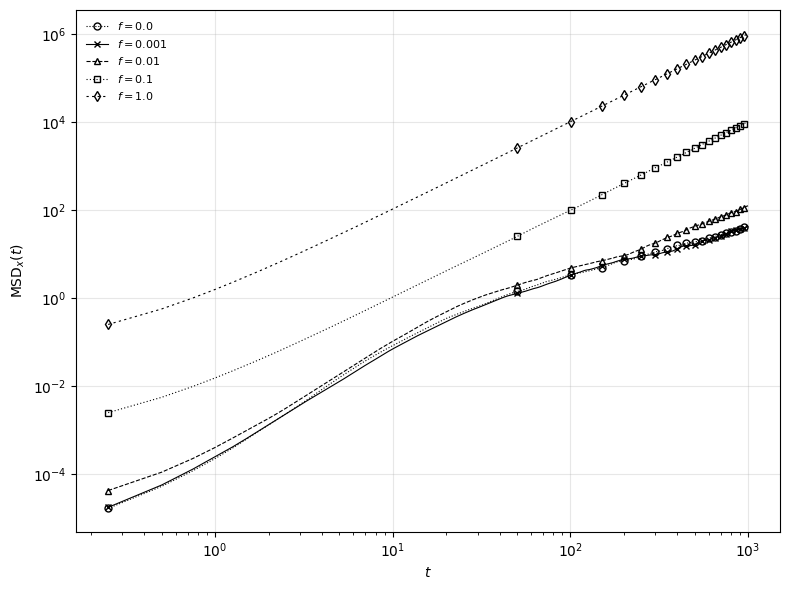

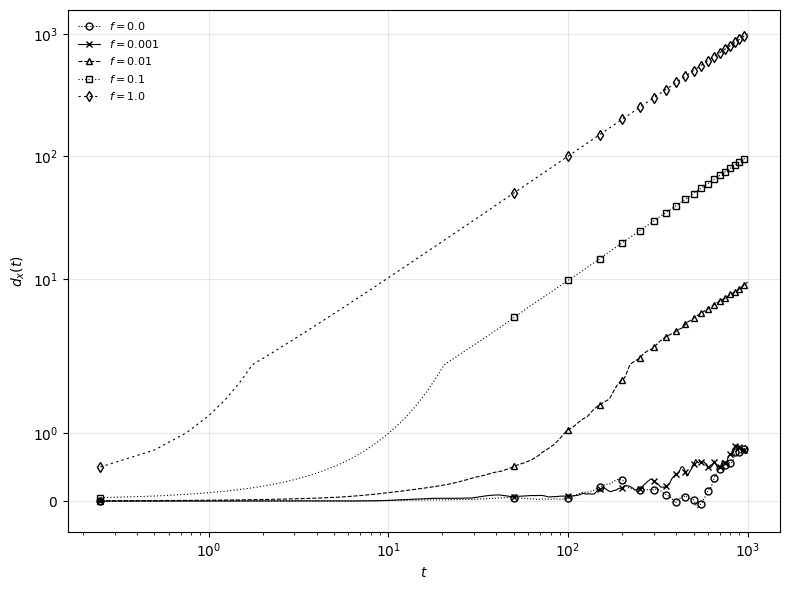

In [33]:
# --- force comparison plots at tau = 10 ---
plt.figure(figsize=(8, 6))
for f_idx, f in enumerate(forces):
    msd_mean = np.mean(force_msd_all[f], axis=0)
    plt.loglog(t[skip:], msd_mean[skip:], marker=plot_styles["markers"]["force"][f_idx % len(plot_styles["markers"]["force"])], 
               markersize=5, markevery=(0, 200), fillstyle="none", 
               linestyle=plot_styles["linestyles"]["force"][f_idx % len(plot_styles["linestyles"]["force"])], 
               linewidth=0.8, color=plot_styles["colors"]["primary"], label=rf"$f={f}$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\mathrm{MSD}_x(t)$")
plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

for f_idx, f in enumerate(forces):
    dx_mean = np.mean(force_dx_all[f], axis=0)
    #if np.min(dx_mean[skip:])<0.0:
    plt.loglog(t[skip:], dx_mean[skip:], 
            marker=plot_styles["markers"]["force"][f_idx % len(plot_styles["markers"]["force"])], 
            markersize=5, markevery=(0, 200), fillstyle="none", 
            linestyle=plot_styles["linestyles"]["force"][f_idx % len(plot_styles["linestyles"]["force"])], 
            linewidth=0.8, color=plot_styles["colors"]["primary"], label=rf"$f={f}$")

plt.xlabel(r"$t$")
plt.ylabel(r"$d_x(t)$")
plt.yscale('symlog')
plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Mu And Diffusion Theory
- Mobility is extracted from the long-time response of `dx/(f t)`.
- The x-diffusion estimate uses the late-time spread of the x displacement.
- For log-log plots, use a positive statistic or clip the floor when the signal reaches the sampling noise level.


In [ ]:

# Parameters (before combined force x tau sweep simulation)
N = 50
L = 100.0
D = 0.01
dt=0.01
T=1000
nsteps = int(T / dt)
taus = [0.25,0.5,1,2,10,100]
tau_force = 10
forces = [0.0, 1e-3, 1e-2, 1e-1, 1.0]
forces_mu = [1e-3, 1e-2, 1e-1, 1.0]
nrealizations = 5
nforce_realizations = 5
store_every = 50
nstore = nsteps // store_every
t = np.arange(nstore) * store_every * dt

In [16]:
# --- combined force x tau response sweep ---
tau_list = taus
force_list = forces
mu_estimates = {tau: [] for tau in tau_list}
Dx_estimates = {tau: [] for tau in tau_list}
t0 = time.time()

nsteps = int(T / dt)
np.random.seed(None)
for tau_idx, tau in enumerate(tau_list):
    for f_idx, f in enumerate(force_list):
        mu_runs = []
        Dx_runs = []
        print(f"tau={tau}: {tau_idx+1}/{len(tau_list)} || f={f}: {f_idx+1}/{len(force_list)}")
        for realization in range(nforce_realizations):
            ftime = time.time()
            #print(f"tau={tau}: {tau_idx+1}/{len(tau_list)} || f={f}: {f_idx+1}/{len(force_list)} || run {realization+1}/{nforce_realizations}", end=" ")
            r = np.random.rand(N, 2) * L - L/2
            xi = np.zeros((N, 2))
            eps = np.random.choice([-1, 1], size=N)
            disp = np.zeros((N, 2))
            for k in range(1, nsteps + 1):
                r_old = r.copy()
                r, xi = euler_mayurama(r, xi, eps, tau, f, dt=dt, D=D, L=L)
                disp += (r - r_old)
                r[:, 0] = ((r[:, 0] + L/2) % L) - L/2
                r[:, 1] = ((r[:, 1] + L/2) % L) - L/2
            if f != 0:
                mu_runs.append(np.mean(eps * disp[:, 0]) / (f * t[-1]))
            Dx_runs.append(np.mean(disp[:, 0] ** 2) / (2 * t[-1]))
            #print(f"- {time.time() - t0:.1f} s")
        if f != 0:
            mu_estimates[tau].append((f, np.mean(mu_runs), np.std(mu_runs)))
        Dx_estimates[tau].append((f, np.mean(Dx_runs), np.std(Dx_runs)))
        
        print(f"--------------------------- {(time.time() - t0)//60:.0f}:{(time.time() - t0)%60:.1f} s")
    print(f"========================================= {(time.time() - t0)//60:.0f}:{(time.time() - t0)%60:.1f} s")
print(f"Finished response sweep in {(time.time() - t0)//60:.0f}:{(time.time() - t0)%60:.1f} s")


tau=1: 1/7 || f=0.0: 1/5
--------------------------- 0:7.0 s
tau=1: 1/7 || f=0.001: 2/5
--------------------------- 0:14.1 s
tau=1: 1/7 || f=0.01: 3/5
--------------------------- 0:21.2 s
tau=1: 1/7 || f=0.1: 4/5
--------------------------- 0:28.2 s
tau=1: 1/7 || f=1.0: 5/5
--------------------------- 0:35.3 s
========================================= 0:1777049795.3 s
tau=2: 2/7 || f=0.0: 1/5
--------------------------- 0:42.3 s
tau=2: 2/7 || f=0.001: 2/5
--------------------------- 0:49.5 s
tau=2: 2/7 || f=0.01: 3/5
--------------------------- 0:56.5 s
tau=2: 2/7 || f=0.1: 4/5
--------------------------- 1:3.6 s
tau=2: 2/7 || f=1.0: 5/5
--------------------------- 1:10.9 s
========================================= 1:1777049830.9 s
tau=5: 3/7 || f=0.0: 1/5
--------------------------- 1:18.0 s
tau=5: 3/7 || f=0.001: 2/5
--------------------------- 1:25.5 s
tau=5: 3/7 || f=0.01: 3/5
--------------------------- 1:32.8 s
tau=5: 3/7 || f=0.1: 4/5
--------------------------- 1:39.8 s
tau=5: 

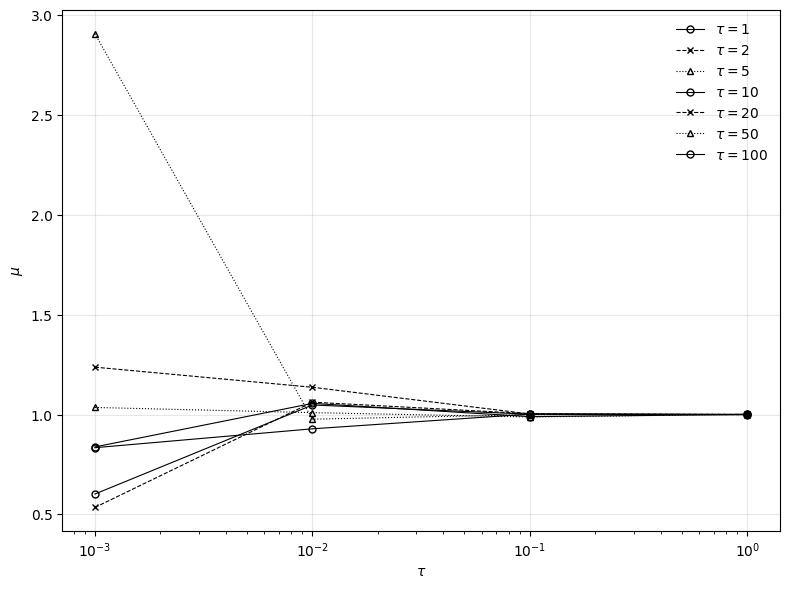

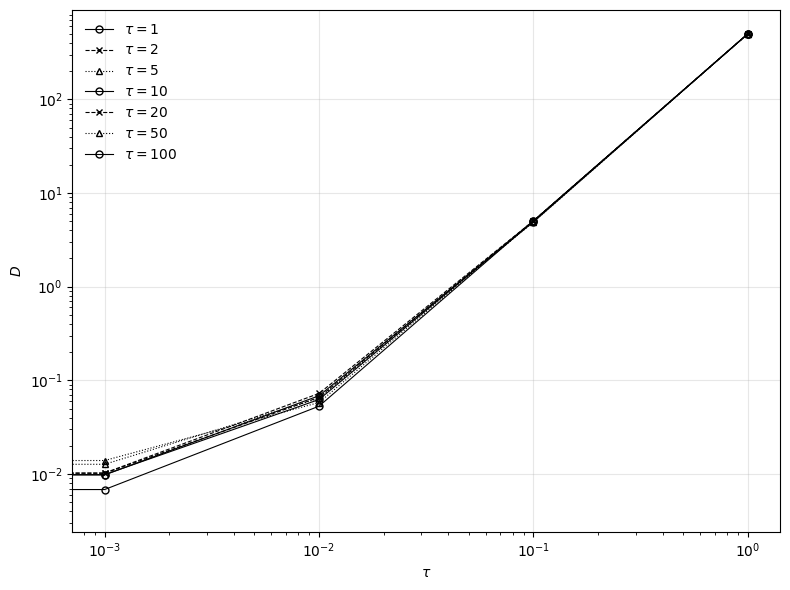

In [17]:
plt.figure(figsize=(8, 6))
for tau_idx, tau in enumerate(tau_list):
    fs = np.array([x[0] for x in mu_estimates[tau]])
    mus = np.array([x[1] for x in mu_estimates[tau]])
    plt.semilogx(fs, np.abs(mus), marker=plot_styles["markers"]["summary"][tau_idx % len(plot_styles["markers"]["summary"])], markersize=5, fillstyle="none", linestyle=plot_styles["linestyles"]["summary"][tau_idx % len(plot_styles["linestyles"]["summary"])], linewidth=0.8, color=plot_styles["colors"]["primary"], label=rf"$\tau={tau}$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\mu$")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for tau_idx, tau in enumerate(tau_list):
    fs = np.array([x[0] for x in Dx_estimates[tau]])
    Ds = np.array([x[1] for x in Dx_estimates[tau]])
    plt.loglog(fs, Ds, marker=plot_styles["markers"]["summary"][tau_idx % len(plot_styles["markers"]["summary"])], markersize=5, fillstyle="none", linestyle=plot_styles["linestyles"]["summary"][tau_idx % len(plot_styles["linestyles"]["summary"])], linewidth=0.8, color=plot_styles["colors"]["primary"], label=rf"$\tau={tau}$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$D$")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
